# Time Serie

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('data/Airpassengers.csv',parse_dates=True, header=0, index_col=0)
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


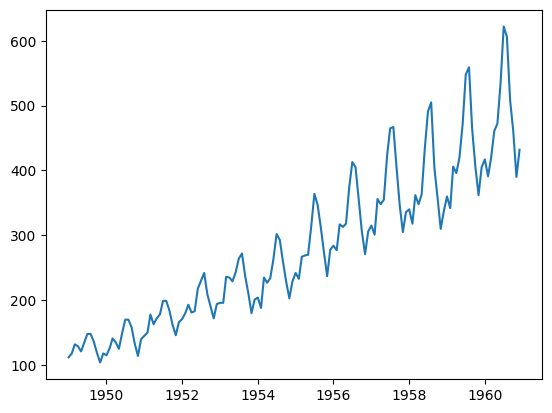

In [10]:
plt.plot(df);

L'analyse de la série temporelle passe donc par la décomposition de la série selon ces trois termes : tendance, saisonnalité et résidu. Le module statsmodels.tsa fournit une implémentation d'une décomposition naïve dans une fonction appelée seasonal_decompose. On procède en trois temps :

- On applique la fonction `seasonal_decompose` à la série à décomposer et on stocke le résultat dans une variable.
- On utilise la méthode plot sur cette variable pour visualiser le résultat.
- On utilise plt.show() pour afficher le graphique correspondant en sortie de cellule.

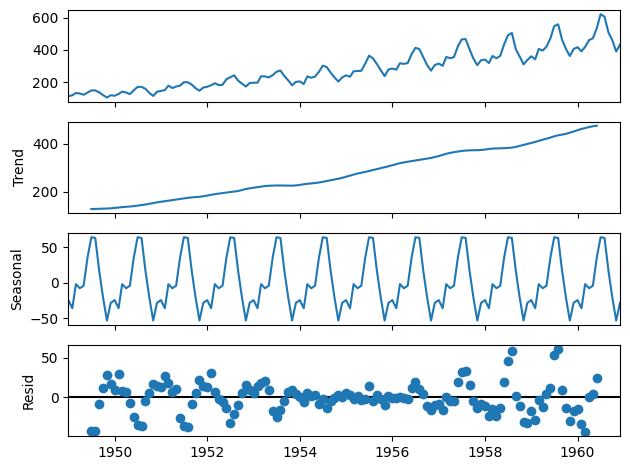

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

res = seasonal_decompose(df)
res.plot()
plt.show()

Comme on peut le voir, la fonction seasonal_decompose nous permet d'obtenir 3 graphiques qui identifient **la tendance**, **la saisonnalité** et **le résidu**.

Ici, on peut rapidement conclure que la décomposition n'a pas été réussie. En effet, le résidu présente de grandes variations en fonction du temps. En théorie, on considère qu'une décomposition est réussie si la partie résiduelle peut être assimilée à ce que l'on appelle un bruit blanc faible.

Un résidu est un bruit blanc (faible) s'il est assimilié à une suite de variables aléatoires non corrélées et de variance finie.

Dans notre cas de figure, nous n'avons visiblement pas un résidu de cette forme : le résidu ne semble absolument pas aléatoire. C'est parce que la fonction ``seasonal_decompose`` utilise par défaut un modèle additif.

Or, un élément devrait nous mettre la puce à l'oreille et nous diriger vers un modèle multiplicatif : l'effet saisonnier semble augmenter avec le temps. Comme nous l'avons vu plus haut, la variation de l'amplitude de l'effet saisonnier est une caractéristique typique des séries multiplicatives.

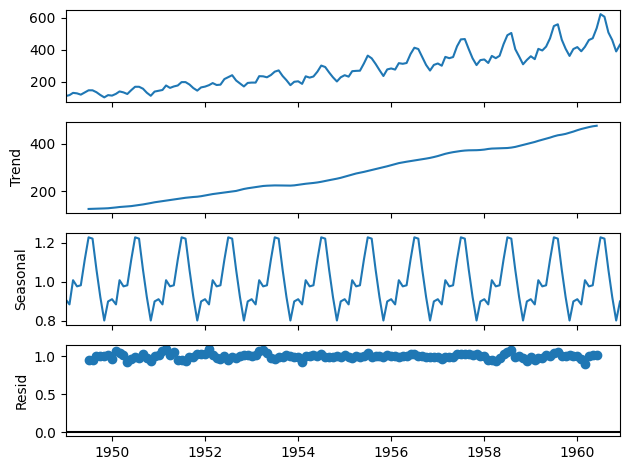

In [14]:
res = seasonal_decompose(df, model = 'multiplicative')
res.plot()
plt.show()

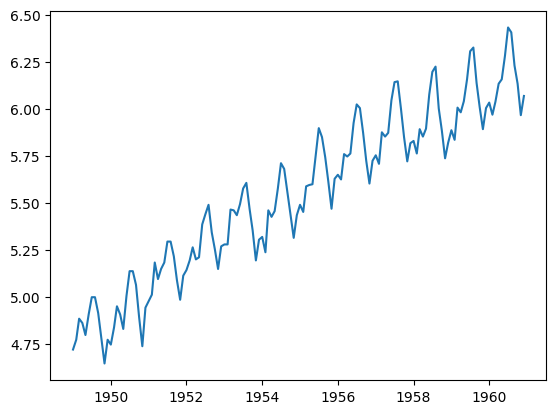

In [16]:
df_log = np.log(df)
plt.plot(df_log);

# Décomposition saisonnière par moyennes mobiles

La question que l’on peut se poser maintenant est la suivante :

**Comment `seasonal_decompose` parvient-elle à identifier la tendance, la saisonnalité et le résidu à partir d’une série temporelle ?**

La réponse repose sur l’utilisation de la **méthode des moyennes mobiles**.

Dans cette section, nous allons reproduire pas à pas cette méthode afin de comprendre précisément ce que fait la fonction `seasonal_decompose`.  
Nous commençons par l’identification de la **tendance** à l’aide de la moyenne mobile.

---

## 1. Moyenne mobile : principe général

La moyenne mobile consiste à remplacer chaque observation d’une série temporelle par la moyenne des valeurs situées dans une **fenêtre mobile** autour de cette observation.

Il existe plusieurs types de moyennes mobiles.  
Dans le cadre de la décomposition saisonnière, on utilise un cas particulier :

**la moyenne mobile centrée**.

Une moyenne mobile centrée \( M_k X_t \) correspond à une combinaison linéaire de valeurs **passées et futures** de la série.

---

## 2. Cas d’une saisonnalité impaire

Lorsque la période de saisonnalité est **impaire**, on a :

$$
k = 2m + 1
$$

La moyenne mobile centrée est alors définie par :

$$
M_k X_t = \frac{1}{k}
\left(
X_{t-m} + \dots + X_{t-1} + X_t + X_{t+1} + \dots + X_{t+m}
\right)
$$

### Interprétation
Chaque valeur \( X_t \) est remplacée par la moyenne de :
- \( m \) valeurs précédentes,
- la valeur courante,
- \( m \) valeurs suivantes.

---

## 3. Cas d’une saisonnalité paire

Lorsque la période de saisonnalité est **paire**, on a :

$$
k = 2m
$$

La moyenne mobile centrée devient :

$$
M_k X_t =
\frac{1}{k}
\left(
\frac{1}{2} X_{t-m}
+ X_{t-m+1}
+ \dots
+ X_t
+ \dots
+ X_{t+m-1}
+ \frac{1}{2} X_{t+m}
\right)
$$

### Interprétation
Dans ce cas :
- on utilise \( m \) valeurs précédentes et \( m \) valeurs suivantes,
- les valeurs **extrêmes** de la fenêtre sont affectées d’un coefficient \( \frac{1}{2} \),
- ce mécanisme permet de conserver le **centrage temporel** de la moyenne.

---

## 4. Valeurs manquantes aux extrémités

Le calcul de la moyenne mobile fait naturellement apparaître des **valeurs manquantes (`NaN`)** aux extrémités de la série.

Cela est logique :
- au début de la série, il n’y a pas suffisamment de valeurs passées,
- à la fin de la série, il n’y a pas suffisamment de valeurs futures.

---

## 5. Rôle de la moyenne mobile

Une moyenne mobile de période \( k \) possède deux propriétés essentielles :

- elle **conserve les tendances linéaires**,
- elle **absorbe les saisonnalités de période \( k \)**.

Ainsi, la moyenne mobile permet de **lisser la série temporelle** et d’isoler sa **tendance**.

---

## 6. Mise en pratique avec pandas

La méthode `rolling` de **pandas** permet de sélectionner les observations autour d’un instant donné.

Combinée avec la méthode `mean`, elle permet de calculer une moyenne mobile.

Le paramètre `center` est un booléen qui indique si la fenêtre de calcul doit être **centrée** sur la valeur courante.

### Exemple conceptuel

```python
serie.rolling(window=k, center=True).mean()

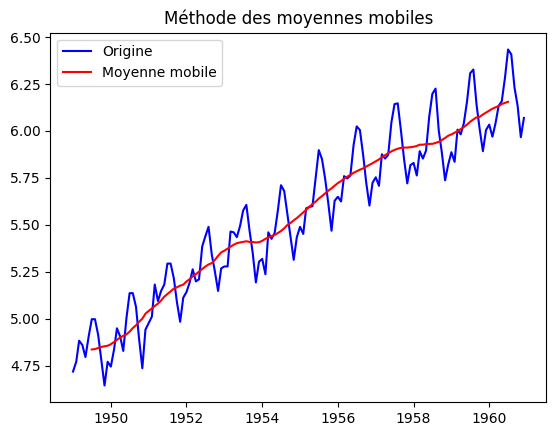

In [19]:
#On a une saisonnalité de période 12

df_ma = df_log.rolling(window = 12, center = True).mean()

#Affichage de la série 

plt.plot(df_log, color = 'blue', label = 'Origine')
plt.plot(df_ma, color = 'red', label = 'Moyenne mobile')
plt.legend()
plt.title('Méthode des moyennes mobiles')
plt.show()

Applique le test ADF, pour vérifier si la série est stationnaire.

In [20]:
import statsmodels.api as sm

_, p_value, _, _, _, _  = sm.tsa.stattools.adfuller(df_log)
print(p_value)  # p-valeur bien inférieure à 0.05, on peut considérer la série comme stationnaire.

0.42236677477039125


ici montre que la série origine n'est pas stationnaire, pour ramené à stationnaire faut faire la différencié.

In [46]:
# for i in range(1, 10):
#     df_log_diff = df_log.diff(i).dropna()
#     _, p_value, _, _, _, _  = sm.tsa.stattools.adfuller(df_log_diff)
#     if p_value < 0.05:
#         print(f'La série est stationnaire après une différenciation de lag {i}. avec une p-value de {p_value}')
#         break

donc pour la différencié à ordre 2 la série est devenu stationnaire.

PS : on peut vérifier aussi avec l'autocorrelation

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

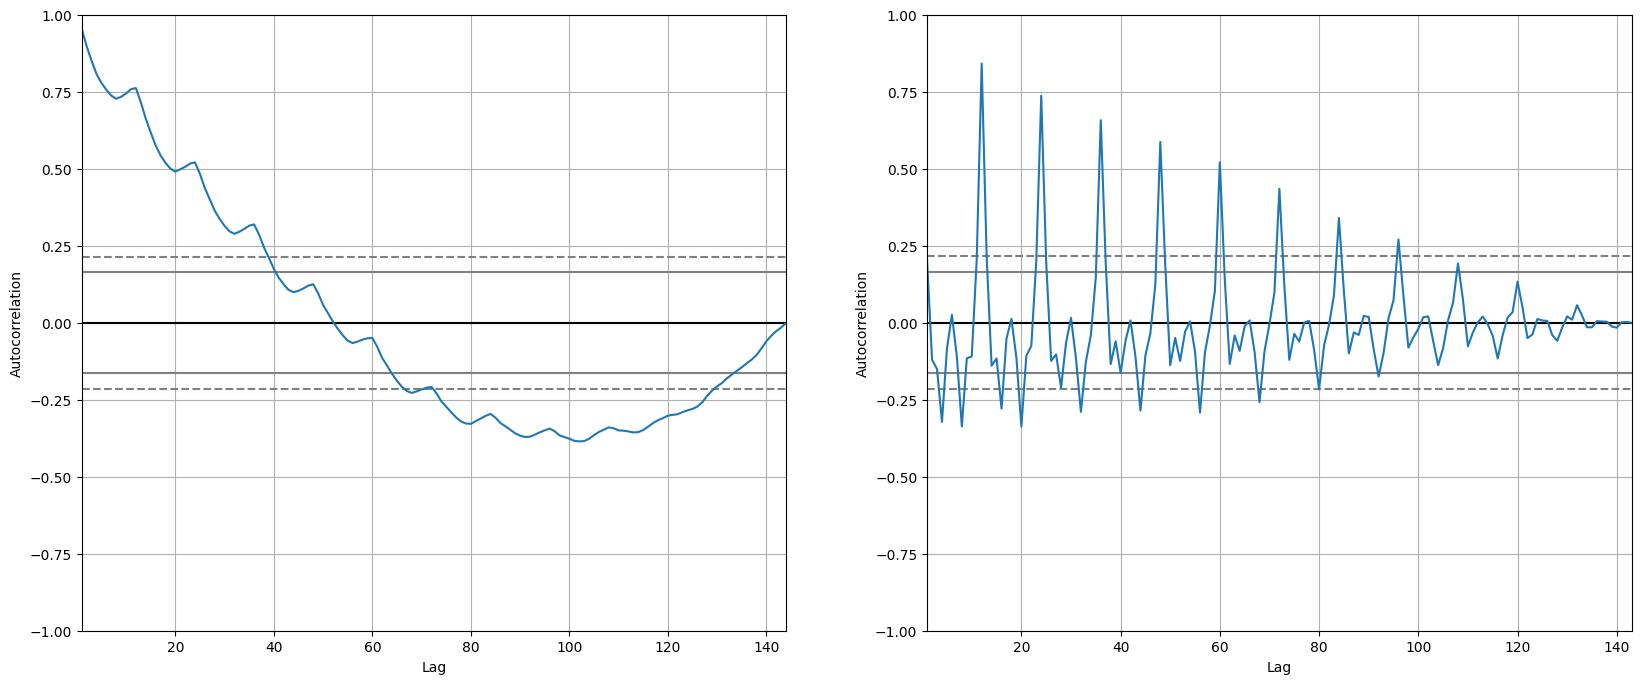

In [45]:
fig = plt.figure(figsize=(20,8), dpi = 100)
plt.subplot(121)
pd.plotting.autocorrelation_plot(df_log)
plt.subplot(122)
pd.plotting.autocorrelation_plot(df_log.diff().dropna())

malgré stationarité en ordre 2 L'autocorrélation simple semble tendre vers 0 mais présente des pics saisonniers importants (On peut aussi voir ces motifs saisonniers directement dans le graphe de la série). Nous allons donc différencier la série temporelle de manière à éliminer la saisonnalité empêchant la stationnarité (pas encore de décroissance rapide vers zéro).

ici au dé-là de différenciation ordre **d=1**  on différencie un saisionnière **D=1** => peroiode **s=12**

En notation type **SARIMA** : **(d = 1, D = 1, s = 12)**

0.00024859123113840924


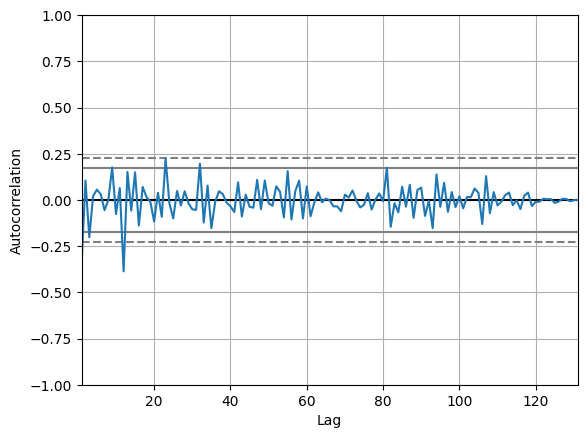

In [ ]:
pd.plotting.autocorrelation_plot(df_log.diff().diff(periods = 12).dropna()) # différeciation ordre 1 et puis saisonnière
_, p_value, _, _, _, _  = sm.tsa.stattools.adfuller(df_log.diff().diff(periods = 12).dropna())
print(p_value)  # p-valeur bien inférieure à 0.05, on

In [47]:
df_stat = df_log.diff().diff(periods = 12).dropna()

Un modèle SARIMA s'écrit sous la forme  $SARIMA(𝑝,𝑑,𝑞)(𝑃,𝐷,𝑄)_𝑘$

Les termes en  **𝑑** et  **𝐷** correspondent aux **degrés de différenciation** utilisés pour stationnariser la série temporelle.

La seconde parenthèse contenant les termes en majuscule correspond à la partie saisonnière de la  SARIMA et  **𝑘** indique **la saisonnalité utilisée**.

**Ainsi le processus  SARIMA combine à la fois une différenciation simple et saisonnière avec un processus  ARMA simple et un processus  ARMA selon la saisonnalité.**

Dans notre exercice nous avions identifié une saisonnalité de période 12 ( 𝑘=12
 ). De plus nous avons fait une différenciation simple ( 𝑑=1
 ) et une différenciation saisonnière ( 𝐷=1
 ) pour stationnariser notre série temporelle.

Ainsi notre modèle sera de la forme  $SARIMA(𝑝,1,𝑞)(𝑃,1,𝑄)_12$
 . Il convient alors de choisir les bons ordres  𝑝
 ,  𝑞
 ,  𝑃
  et  𝑄
  pour nos processus ARMA.

Pour déterminer les ordres d'un processus  AR ou  MA, il est possible de s'appuyer à nouveau sur ses diagrammes d'autocorrélation (ou autocorrélogrammes).

Mathématiquement pour une série temporelle suivant un processus  AR(𝑝), son autocorrélation simple (ACF) décroit vers 0, et son autocorrélation partielle (PACF) s'annule après le rang  𝑝.

Pour une série temporelle suivant un processus  MA(𝑞), son autocorrélation simple (ACF) s'annule après le rang 𝑞 et son autocorrélation partielle (PACF) décroit vers 0.

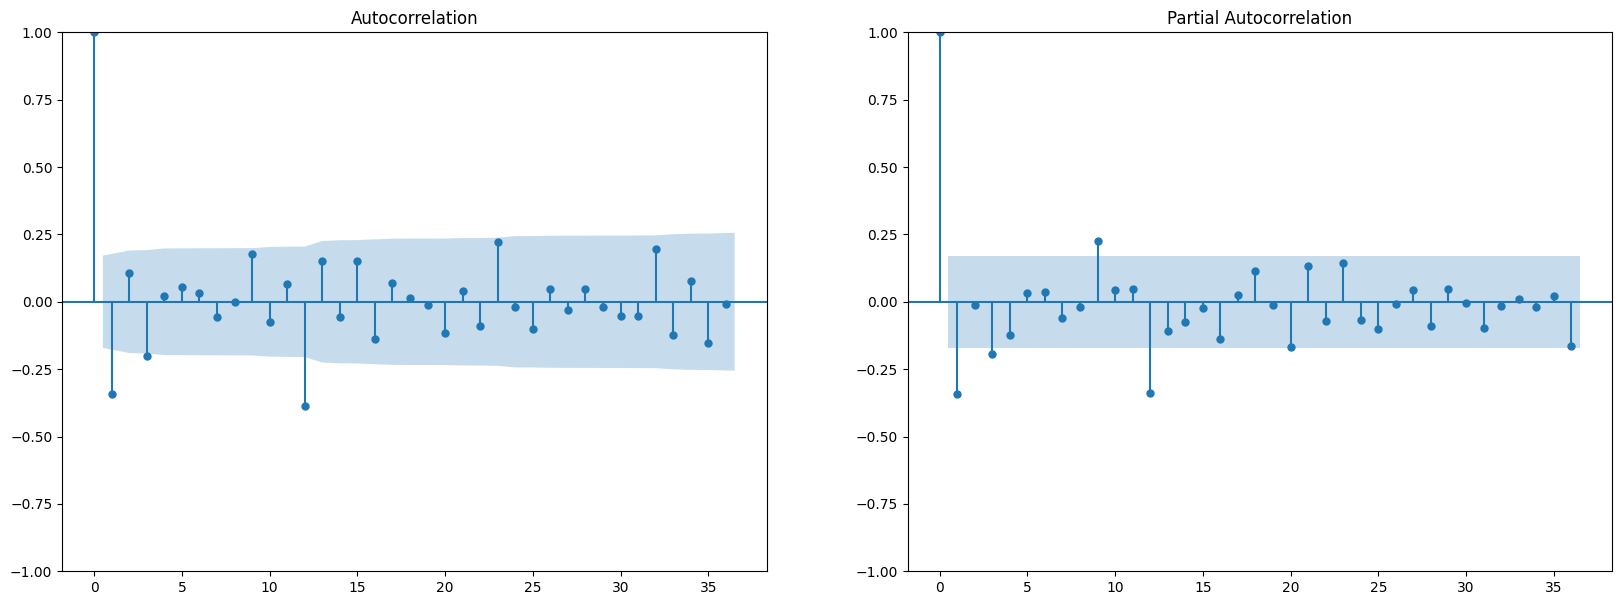

In [48]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,7))

plot_acf(df_stat, lags = 36, ax=ax1)
plot_pacf(df_stat, lags = 36, ax=ax2)
plt.show()


Ainsi pour les ordres  𝑝,  𝑞,  𝑃 et  𝑄 nous avons:

- Une décroissance de l'ACF et la PACF sans coupure nette : modèle  ARMA(1,1)
  , (on prend  𝑝=𝑞=1
  pour débuter mais il est possible de rajouter des termes si le modèle ne semble pas suffisamment performant).

- Pour les pics saisonniers (12, 24, 36), une coupure de l'ACF après la première période et une décroissance de la PACF : modèle  MA(1) (au bout de 12ème, 24ème,.. pics) ie pour $P$, $Q$ on regarde de même manière mais pour pic saisionnière
 

**Nous allons donc entraîner un modèle  $SARIMA(1,1,1)(0,1,1)_12$.**

**Attension** :  quand on applique les modèle $ARIMA$ or $SARIMA$ on reprendre la série non différentielle car dans ces modèle il s'applique la différencielle automatiquement d'où vient le terme **I**

In [49]:
model=sm.tsa.SARIMAX(df_log,order=(1,1,1),seasonal_order=(0,1,1,12))
sarima=model.fit()
print(sarima.summary())

z:\ML\.env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
z:\ML\.env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 244.946
Date:                            Sun, 22 Feb 2026   AIC                           -481.893
Time:                                    23:55:06   BIC                           -470.392
Sample:                                01-01-1949   HQIC                          -477.220
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1968      0.199      0.989      0.323      -0.193       0.587
ma.L1         -0.5790      0.172   

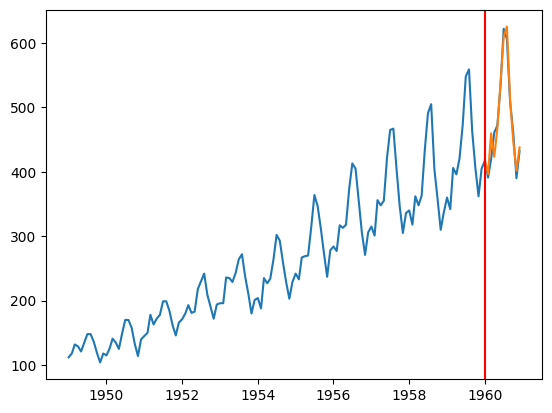

In [ ]:
import datetime

pred = np.exp(sarima.predict(132, 143)) #Prédiction et passage à l'exponentielle pour ramené les valeurs à l'échelle d'origine (start = 132 car on commence à 0 et on a 144 mois)
df_pred = pd.concat([df, pred])#Concaténation des prédictions
plt.plot(df_pred) #Visualisation
plt.axvline(x= datetime.date(1960,1,1), color='red'); # Ajout de la ligne verticale

En plus de la méthode ``predict`` de statsmodels qui peut prédire sur n'importe quelle période, il existe la méthode ``get_forecast`` qui prédit out of the bag c'est à dire qui complète la série temporelle.

Il est aussi possible de représenter un intervalle de confiance autour de la prédiction en se basant sur les méthodes ``get_forecastet`` et ``get_prediction``.

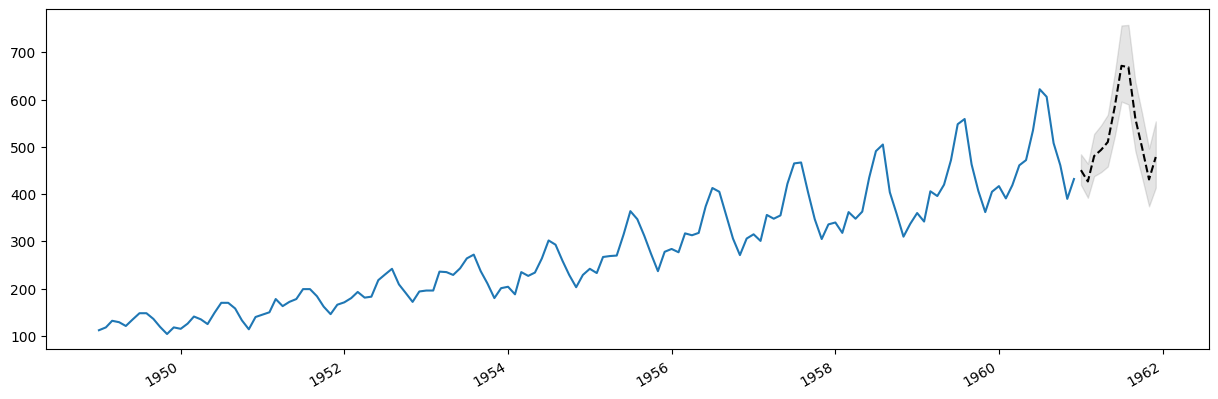

In [54]:
prediction = sarima.get_forecast(steps =12).summary_frame()  #Prédiction avec intervalle de confiance
fig, ax = plt.subplots(figsize = (15,5))
plt.plot(df)
prediction = np.exp(prediction) #Passage à l'exponentielle
prediction['mean'].plot(ax = ax, style = 'k--') #Visualisation de la moyenne
ax.fill_between(prediction.index, prediction['mean_ci_lower'], prediction['mean_ci_upper'], color='k', alpha=0.1); #Visualisation de l'intervalle de confiance